In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matlab.engine

from glob import glob

import sys
sys.path.append('../../wavelet/')
import wavelet_funcs as wf

import os
from scipy.ndimage import gaussian_filter

In [28]:
eng = matlab.engine.start_matlab()

### Load some data

In [24]:
p = '../../data/20241015a_vehicle_vessel1_REG_INTERP_TimeSeries.nc'
ds = xr.open_dataset(p)
x = ds.tlsc_xymean**(-2)

In [25]:
t_inject_ = 490 # dummy

In [26]:
dt = 0.5
Fs = 2
nt = 4012
t = np.arange(x.size)*dt
x = x.data


## Dummy signal
# fsignal = 0.03
# amp = 5
# x = 50 + amp*np.cos(2*np.pi*fsignal*t)

In [41]:
res = wf.matlab_cwt(eng, x, Fs)
t_coi_injection, coi_injection = wf.coi_around_injection(res.t.data, res.coi.data, t_inject_)

(-0.25, 2194.75)

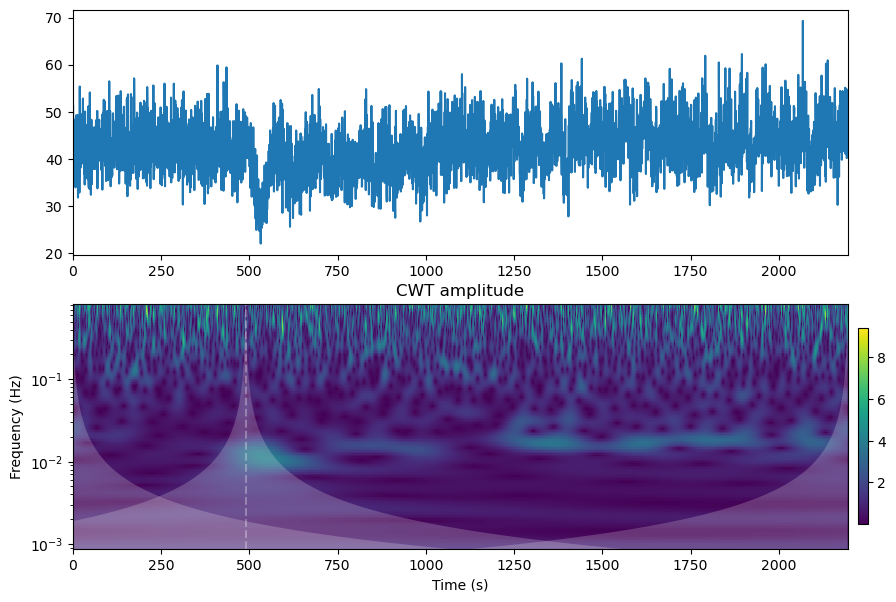

In [45]:
f, (ax0, ax) = plt.subplots(2,1,figsize=(10,7))
ax0.plot(t,x)
# wf.plot_cwt((res.wt_amp**2)*res.scale.data.reshape((res.scale.size, 1)), res.f, res.t, add_colorbar=True, ax=ax) # Power L2 norm
wf.plot_cwt(res.wt_amp, res.f, res.t, add_colorbar=True, ax=ax) # Amplitude L1 norm
ax.set_yscale('log')

ax.fill_between(t, y1=res.coi, color='w', alpha=0.2, lw=0)
ax.fill_between(t_coi_injection, coi_injection,color='w', alpha=0.2, lw=0)
ax.axvline(t_inject_, color='w', ls='--', alpha=0.3)

ax.set_ylim([res.f.min(), res.f.max()])
# ax.set_ylim([0.008, 0.105)
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("CWT amplitude")

ax0.set_xlim(ax.get_xlim())
# plt.savefig('test.jpg', dpi=600, bbox_inches='tight')

In [23]:
eng.quit()